### Validation Plotting

Training logs were lost due to a bug in the FileLogger. Hotfixing for weekly meeting: analyze passrates over validation logs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root = "/ptmp/rfechner/out/dryrun"
dirs = os.listdir(root)

logpaths = {
    d : os.path.join(root, d, 'logs.jsonl') for d in dirs
}

valpaths = [
    os.path.join(root, d, 'val_jsonl') for d in dirs
]

In [3]:
import pandas as pd
import numpy as np

In [4]:
def mean_validation_score(filepath : str):
    
    precomputed_jsonfiles = list(filter(lambda x: 'precomp' in x, os.listdir(filepath)))
    jsonfiles = list(filter(lambda x: 'precomp' not in x, os.listdir(filepath)))
    precomputed_jsonfiles = list(sorted(precomputed_jsonfiles, key=lambda x: int(x.split('_')[0])))
    jsonfiles = list(sorted(jsonfiles, key=lambda x: int(x.split('.')[0])))
    
    precomputed_logprobs, precomputed_entropy, validation_means = [], [], []
    
    for f in jsonfiles:
        with open(os.path.join(filepath, f)) as file:
            validation_means.append(
                pd.read_json(file, lines=True)['reward'].mean()
            )
    # god forgive my sins
    for f in precomputed_jsonfiles:
        with open(os.path.join(filepath, f)) as file:
            df = pd.read_json(file, lines=True)
            l, e = df['logprobs'], df['entropy']
            l1, l2 = np.array(l[0][:4]).mean(), np.array(l[0][4:]).mean()
            e1, e2 = np.array(e[0][:4]).mean(), np.array(e[0][4:]).mean()
            precomputed_logprobs.append(
                (l1+  l2) / 2
            )
            precomputed_entropy.append(
                (e1+  e2) / 2
            )
    return precomputed_logprobs, precomputed_entropy, validation_means

In [5]:
import pathlib
from tqdm import tqdm_notebook as tqdm

In [6]:
pathlib.Path(valpaths[0]).parts[-2]

'llama_3.2_1b_instruct__kl-cov'

In [7]:
def calc_method_metrics():
    metrics = {}
    for vp in tqdm(valpaths):
        method = pathlib.Path(vp).parts[-2]
        try:
            lp, e, valacc = mean_validation_score(vp)
        except:
            print('failed method: ', method)
            
        metrics[method] = {
            'logprobs' : lp,
            'entropy' : e,
            'valacc' : valacc
        }
    return metrics
metrics = calc_method_metrics()

/tmp/ipykernel_137221/3451550111.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for vp in tqdm(valpaths):


  0%|          | 0/9 [00:00<?, ?it/s]

failed method:  llama_3.2_1b_instruct__dapo


In [8]:
metrics.keys()

dict_keys(['llama_3.2_1b_instruct__kl-cov', 'llama_3.2_1b_instruct__entropy_reg', 'llama_3.2_1b_instruct__gtpo', 'llama_3.2_1b_instruct__dapo', 'llama_3.2_1b_instruct__grpo', 'llama_3.2_1b_instruct__clip-cov', 'llama_3.2_1b_instruct__grpo-s', 'llama_3.2_1b_instruct__drgrpo', 'llama_3.2_1b_instruct__gspo'])

In [9]:
metrics['llama_3.2_1b_instruct__grpo']

{'logprobs': [np.float64(-13.25),
  np.float64(-13.2421875),
  np.float64(-13.2109375),
  np.float64(-13.2734375),
  np.float64(-13.2578125),
  np.float64(-13.42578125),
  np.float64(-13.390625),
  np.float64(-13.57421875),
  np.float64(-13.8125),
  np.float64(-13.9375),
  np.float64(-14.0390625),
  np.float64(-14.15625),
  np.float64(-14.390625),
  np.float64(-14.6484375),
  np.float64(-14.859375),
  np.float64(-15.03125),
  np.float64(-14.984375),
  np.float64(-15.0),
  np.float64(-15.171875),
  np.float64(-15.234375),
  np.float64(-15.609375),
  np.float64(-15.71875),
  np.float64(-15.75),
  np.float64(-15.9140625),
  np.float64(-16.15625),
  np.float64(-16.2578125),
  np.float64(-16.796875),
  np.float64(-16.96875),
  np.float64(-17.015625),
  np.float64(-17.0625),
  np.float64(-17.484375),
  np.float64(-17.8203125),
  np.float64(-17.9296875),
  np.float64(-18.140625),
  np.float64(-18.34375),
  np.float64(-18.3046875),
  np.float64(-18.3671875),
  np.float64(-18.328125),
  np.floa

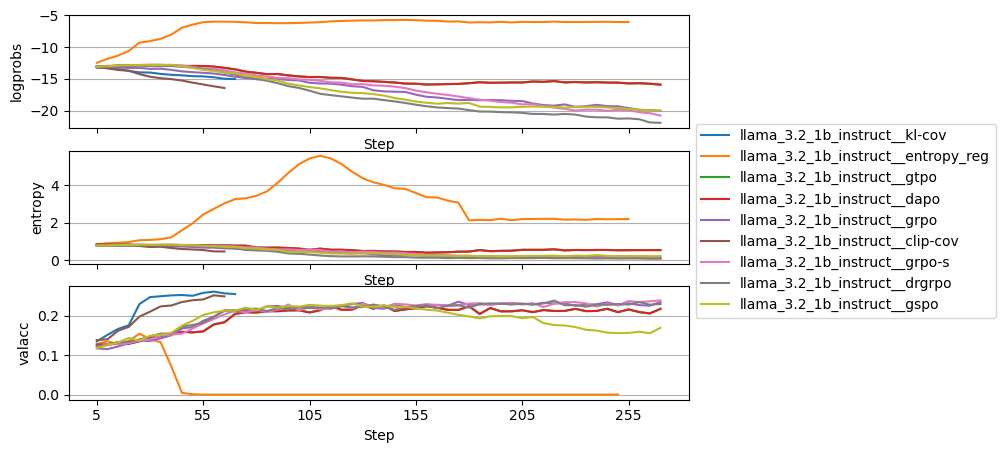

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)
keys = ['logprobs', 'entropy', 'valacc']
labels = {
    'logprobs' : "Log-probs for incorrect answer",
    "entropy" : "Entropy over incorrect tokens",
    "valacc" : "Mean validation accuracy over 5 Datasets"
}
xticks, xticks_values = range(0, 53, 10), range(5, 270, 50)

for i, key in enumerate(keys):
    for k, v in metrics.items():
        values = v[key]
        axes[i].plot(range(len(values)), values, label=k)
    axes[i].set_xticks(xticks, xticks_values)
    axes[i].set_ylabel(key)
    axes[i].set_xlabel('Step')
    axes[i].grid(visible=True, axis='y')
axes[-1].legend(bbox_to_anchor=(1, 2.5))
plt.plot()
plt.show()

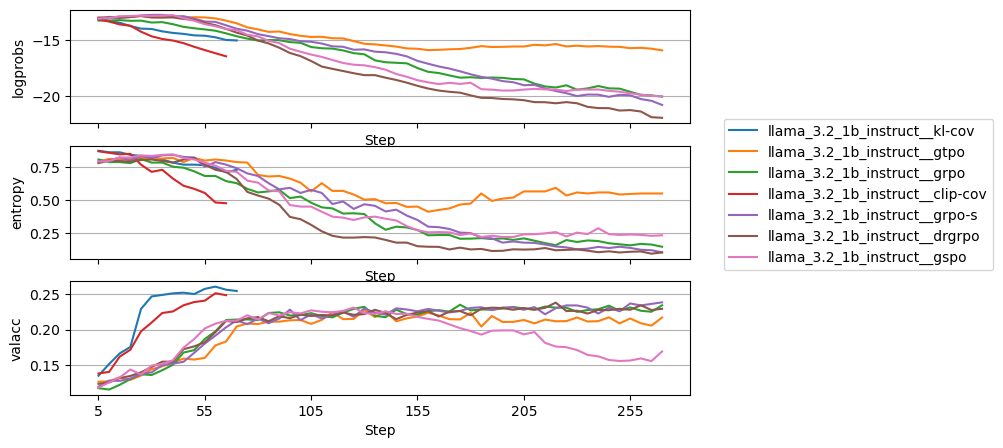

In [26]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)
keys = ['logprobs', 'entropy', 'valacc']
labels = {
    'logprobs' : "Log-probs for incorrect answer",
    "entropy" : "Entropy over incorrect tokens",
    "valacc" : "Mean validation accuracy over 5 Datasets"
}
xticks, xticks_values = range(0, 53, 10), range(5, 270, 50)

for i, key in enumerate(keys):
    for k, v in metrics.items():
        if 'entropy' in k or 'dapo' in k:
            continue
        values = v[key]
        axes[i].plot(range(len(values)), values, label=k)
    axes[i].set_xticks(xticks, xticks_values)
    axes[i].set_ylabel(key)
    axes[i].set_xlabel('Step')
    axes[i].grid(visible=True, axis='y')
axes[-1].legend(bbox_to_anchor=(1.5, 2.5))
plt.plot()
plt.show()

In [12]:
logpaths

{'llama_3.2_1b_instruct__kl-cov': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__kl-cov/logs.jsonl',
 'llama_3.2_1b_instruct__entropy_reg': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__entropy_reg/logs.jsonl',
 'llama_3.2_1b_instruct__gtpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__gtpo/logs.jsonl',
 'llama_3.2_1b_instruct__dapo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__dapo/logs.jsonl',
 'llama_3.2_1b_instruct__grpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__grpo/logs.jsonl',
 'llama_3.2_1b_instruct__clip-cov': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__clip-cov/logs.jsonl',
 'llama_3.2_1b_instruct__grpo-s': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__grpo-s/logs.jsonl',
 'llama_3.2_1b_instruct__drgrpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__drgrpo/logs.jsonl',
 'llama_3.2_1b_instruct__gspo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__gspo/logs.jsonl'}

In [13]:
with open(logpaths['llama_3.2_1b_instruct__clip-cov'], 'r') as file:
    tmp = pd.read_json(file, lines=True)

In [14]:
tmp['data'][0]

{'global_seqlen/min': 442683,
 'global_seqlen/max': 503890,
 'global_seqlen/minmax_diff': 61207,
 'global_seqlen/balanced_min': 463672,
 'global_seqlen/balanced_max': 463673,
 'global_seqlen/mean': 463672.375,
 'actor/pg_loss': 0.000691112558816,
 'actor/pg_clipfrac': 0.00021722340005400002,
 'actor/ppo_kl': 3.6748888170077714e-05,
 'actor/pg_clipfrac_lower': 0.0,
 'actor/grad_norm': 0.20572961866855602,
 'perf/mfu/actor': 0.12988254729891502,
 'perf/max_memory_allocated_gb': 31.376125812530518,
 'perf/max_memory_reserved_gb': 32.77734375,
 'perf/cpu_memory_used_gb': 35.38842010498047,
 'actor/lr': 1e-06,
 'val-aux/math-ai/math500/reward/mean@8': 0.17200000000000001,
 'val-aux/math-ai/math500/reward/std@8': 0.193193627094897,
 'val-aux/math-ai/math500/reward/best@2/mean': 0.251961999999999,
 'val-aux/math-ai/math500/reward/best@2/std': 0.197752608105768,
 'val-aux/math-ai/math500/reward/worst@2/mean': 0.09168599999999999,
 'val-aux/math-ai/math500/reward/worst@2/std': 0.129725733800135

In [15]:
cols = pd.DataFrame(data=tmp['data'].to_list())

In [16]:
cols.columns.to_list()

['global_seqlen/min',
 'global_seqlen/max',
 'global_seqlen/minmax_diff',
 'global_seqlen/balanced_min',
 'global_seqlen/balanced_max',
 'global_seqlen/mean',
 'actor/pg_loss',
 'actor/pg_clipfrac',
 'actor/ppo_kl',
 'actor/pg_clipfrac_lower',
 'actor/grad_norm',
 'perf/mfu/actor',
 'perf/max_memory_allocated_gb',
 'perf/max_memory_reserved_gb',
 'perf/cpu_memory_used_gb',
 'actor/lr',
 'val-aux/math-ai/math500/reward/mean@8',
 'val-aux/math-ai/math500/reward/std@8',
 'val-aux/math-ai/math500/reward/best@2/mean',
 'val-aux/math-ai/math500/reward/best@2/std',
 'val-aux/math-ai/math500/reward/worst@2/mean',
 'val-aux/math-ai/math500/reward/worst@2/std',
 'val-aux/math-ai/math500/reward/best@4/mean',
 'val-aux/math-ai/math500/reward/best@4/std',
 'val-aux/math-ai/math500/reward/worst@4/mean',
 'val-aux/math-ai/math500/reward/worst@4/std',
 'val-aux/math-ai/math500/reward/best@8/mean',
 'val-aux/math-ai/math500/reward/best@8/std',
 'val-aux/math-ai/math500/reward/worst@8/mean',
 'val-aux/m

In [17]:
steps = pd.DataFrame(tmp['step'], columns=['step'])

In [18]:
pd.concat([steps, cols], axis=1)

,step,global_seqlen/min,global_seqlen/max,global_seqlen/minmax_diff,global_seqlen/balanced_min,global_seqlen/balanced_max,global_seqlen/mean,actor/pg_loss,actor/pg_clipfrac,actor/ppo_kl,...,timing_s/testing,timing_per_token_ms/adv,timing_per_token_ms/update_actor,timing_per_token_ms/gen,perf/total_num_tokens,perf/time_per_step,perf/throughput,train/num_gen_batches,timing_s/save_checkpoint,actor/entropy
0,1,442683,503890,61207,463672,463673,463672.375,0.000691,0.000217,0.000037,...,485.853732,0.000042,0.030184,0.448702,3709379,2178.431799,212.846863,9,NaN,NaN
1,2,423026,511943,88917,470920,470921,470920.375,0.000984,0.000216,-0.000053,...,461.707295,0.000038,0.030352,0.384690,3767363,1951.661487,241.292037,8,NaN,NaN
2,3,431939,477067,45128,463907,463908,463907.125,0.000163,0.000213,0.000043,...,457.265579,0.000041,0.029964,0.382984,3711257,1935.261262,239.712918,8,NaN,NaN
3,4,429909,488739,58830,452914,452915,452914.625,0.001895,0.000227,0.000039,...,454.662548,0.000042,0.030274,0.326186,3623317,1707.492342,265.251336,7,NaN,NaN
4,5,396858,472282,75424,430512,430513,430512.375,0.000050,0.000237,0.000095,...,445.775091,0.000044,0.029373,0.349432,3444099,1709.825418,251.787329,7,2.101419,NaN
5,6,388258,459064,70806,421051,421052,421051.125,0.000185,0.000273,0.000100,...,466.950715,0.000045,0.030388,0.238831,3368409,1369.488020,307.451485,5,NaN,NaN
6,7,383526,464780,81254,421538,421539,421538.375,0.000465,0.000272,0.000063,...,463.125074,0.000045,0.029745,0.227281,3372307,1338.119987,315.022852,5,NaN,NaN
7,8,379727,453591,73864,415353,415354,415353.500,0.001602,0.000281,0.000015,...,478.245555,0.000046,0.029791,0.231705,3322828,1341.235341,309.679806,5,NaN,NaN
8,6,385918,465493,79575,437189,437190,437189.625,0.000764,0.000246,0.000029,...,445.104216,0.000042,0.030926,0.281613,3497517,1534.743774,284.861638,6,NaN,17920.0
9,7,388369,479658,91289,424860,424861,424860.500,-0.000170,0.000255,-0.000007,...,439.424451,0.000044,0.030135,0.245446,3398884,1374.456761,309.111579,5,NaN,12800.0


In [19]:
print(cols.columns.to_list())

['global_seqlen/min', 'global_seqlen/max', 'global_seqlen/minmax_diff', 'global_seqlen/balanced_min', 'global_seqlen/balanced_max', 'global_seqlen/mean', 'actor/pg_loss', 'actor/pg_clipfrac', 'actor/ppo_kl', 'actor/pg_clipfrac_lower', 'actor/grad_norm', 'perf/mfu/actor', 'perf/max_memory_allocated_gb', 'perf/max_memory_reserved_gb', 'perf/cpu_memory_used_gb', 'actor/lr', 'val-aux/math-ai/math500/reward/mean@8', 'val-aux/math-ai/math500/reward/std@8', 'val-aux/math-ai/math500/reward/best@2/mean', 'val-aux/math-ai/math500/reward/best@2/std', 'val-aux/math-ai/math500/reward/worst@2/mean', 'val-aux/math-ai/math500/reward/worst@2/std', 'val-aux/math-ai/math500/reward/best@4/mean', 'val-aux/math-ai/math500/reward/best@4/std', 'val-aux/math-ai/math500/reward/worst@4/mean', 'val-aux/math-ai/math500/reward/worst@4/std', 'val-aux/math-ai/math500/reward/best@8/mean', 'val-aux/math-ai/math500/reward/best@8/std', 'val-aux/math-ai/math500/reward/worst@8/mean', 'val-aux/math-ai/math500/reward/worst@8

In [20]:
logpaths

{'llama_3.2_1b_instruct__kl-cov': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__kl-cov/logs.jsonl',
 'llama_3.2_1b_instruct__entropy_reg': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__entropy_reg/logs.jsonl',
 'llama_3.2_1b_instruct__gtpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__gtpo/logs.jsonl',
 'llama_3.2_1b_instruct__dapo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__dapo/logs.jsonl',
 'llama_3.2_1b_instruct__grpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__grpo/logs.jsonl',
 'llama_3.2_1b_instruct__clip-cov': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__clip-cov/logs.jsonl',
 'llama_3.2_1b_instruct__grpo-s': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__grpo-s/logs.jsonl',
 'llama_3.2_1b_instruct__drgrpo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__drgrpo/logs.jsonl',
 'llama_3.2_1b_instruct__gspo': '/ptmp/rfechner/out/dryrun/llama_3.2_1b_instruct__gspo/logs.jsonl'}

In [21]:
from pathlib import Path
logmetrics = {}
for method, l in logpaths.items():
    try:
        with open(l, 'r') as file:
            tmp = pd.read_json(file, lines=True)['data'].to_list()
            df = pd.DataFrame(tmp)
            logmetrics[method] = df
    except:
        print(f"Failed method: {method}")

In [22]:
logmetrics['llama_3.2_1b_instruct__kl-cov']

,global_seqlen/min,global_seqlen/max,global_seqlen/minmax_diff,global_seqlen/balanced_min,global_seqlen/balanced_max,global_seqlen/mean,actor/pg_loss,actor/pg_clipfrac,actor/ppo_kl,actor/pg_clipfrac_lower,...,timing_s/testing,timing_per_token_ms/adv,timing_per_token_ms/gen,timing_per_token_ms/update_actor,perf/total_num_tokens,perf/time_per_step,perf/throughput,train/num_gen_batches,timing_s/save_checkpoint,actor/entropy
0,442683,503890,61207,463672,463673,463672.375,0.000690,0.0,0.006946,0.0,...,467.166713,0.000041,0.451657,0.029926,3709379,2168.569473,213.814859,9,NaN,NaN
1,427399,516565,89166,474583,474584,474583.500,0.000936,0.0,0.008649,0.0,...,472.688156,0.000041,0.383579,0.030029,3796668,1972.051412,240.654730,8,NaN,NaN
2,447025,494425,47400,473803,473804,473803.250,0.000944,0.0,0.009223,0.0,...,489.827338,0.000044,0.385479,0.029498,3790426,2003.937415,236.436151,8,NaN,NaN
3,464920,510329,45409,481193,481194,481193.250,0.002040,0.0,0.008214,0.0,...,468.018985,0.000043,0.328894,0.029235,3849546,1809.897747,265.867644,7,NaN,NaN
4,452923,538428,85505,491426,491427,491426.500,0.001412,0.0,0.010224,0.0,...,494.543272,0.000043,0.291059,0.029177,3931412,1735.822288,283.108763,6,3.187681,NaN
5,496108,554728,58620,519792,519792,519792.000,0.000503,0.0,0.009839,0.0,...,480.027385,0.000037,0.219193,0.029826,4158336,1524.126607,341.042534,5,NaN,NaN
6,469564,555509,85945,511071,511071,511071.000,-0.000383,0.0,0.009086,0.0,...,498.725656,0.000037,0.233257,0.029568,4088568,1585.303972,322.380445,5,NaN,NaN
7,445890,544194,98304,493056,493057,493056.875,0.000390,0.0,0.007179,0.0,...,474.763930,0.000038,0.234605,0.029840,3944455,1527.287182,322.831803,5,NaN,NaN
8,488527,536865,48338,505717,505718,505717.250,0.001057,0.0,0.008549,0.0,...,472.935314,0.000043,0.231558,0.030012,4045738,1548.829019,326.515867,5,NaN,21120.0
9,492144,533481,41337,509464,509465,509464.625,0.001504,0.0,0.009210,0.0,...,494.489142,0.000040,0.238499,0.030074,4075717,1593.476435,319.718958,5,NaN,17024.0


In [48]:
list(filter(lambda x: 'response' in x, logmetrics['llama_3.2_1b_instruct__grpo'].columns))

['response_length/mean',
 'response_length/max',
 'response_length/min',
 'response_length/clip_ratio',
 'response_length_non_aborted/mean',
 'response_length_non_aborted/max',
 'response_length_non_aborted/min',
 'response_length_non_aborted/clip_ratio',
 'response/aborted_ratio']

failed method: llama_3.2_1b_instruct__gtpo
failed method: llama_3.2_1b_instruct__grpo
failed method: llama_3.2_1b_instruct__grpo-s
failed method: llama_3.2_1b_instruct__drgrpo
failed method: llama_3.2_1b_instruct__gspo


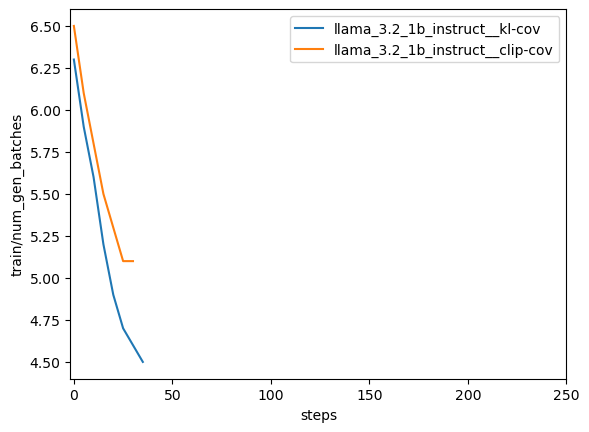

In [52]:
key = 'train/num_gen_batches'
for k in logmetrics.keys():
    if 'entropy' in k or 'dapo' in k:
        continue
    try: 
        values = logmetrics[k][key]
        kernel = np.ones(10) / 10
        values_smoothened = np.convolve(np.array(values), kernel, mode='valid')
        plt.plot(values_smoothened, label=k)
    except:
        print(f'failed method: {k}')
    
plt.xticks(range(0, 60, 10), range(0, 60 * 5, 10 * 5))
plt.xlabel('steps')
plt.ylabel(key)
plt.legend()
plt.show()


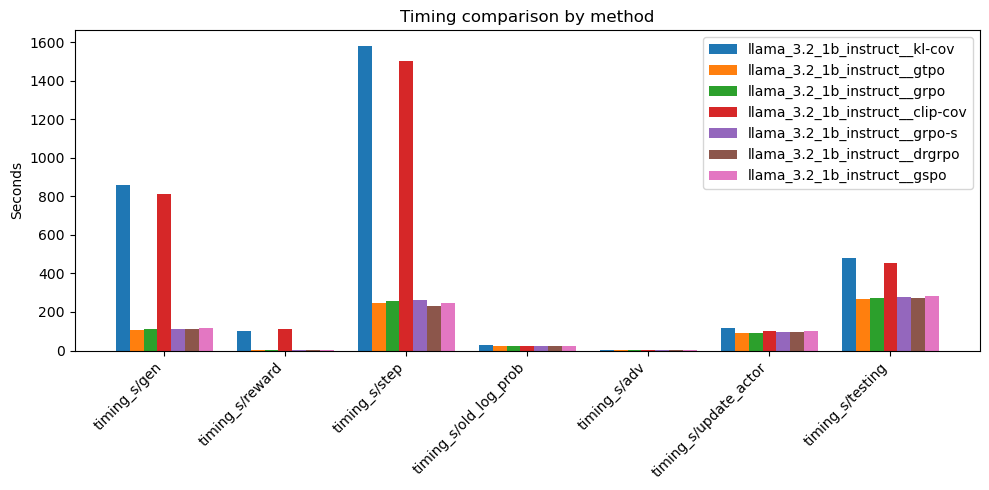

In [51]:
timing_keys = [
'timing_s/gen',
'timing_s/reward',
'timing_s/step',
'timing_s/old_log_prob',
'timing_s/adv',
'timing_s/update_actor',
'timing_s/testing']

methods = [m for m in logmetrics.keys() if 'entropy' not in m and 'dapo' not in m]

x = np.arange(len(timing_keys))  # positions for timing categories
bar_width = 0.8 / len(methods)   # width of each method's bar within a group

plt.figure(figsize=(10, 5))

for i, method in enumerate(methods):
    try:
        values = [logmetrics[method].get(k, 0) for k in timing_keys]
        values_mean = [np.mean(vs) for vs in values]
        plt.bar(x + i * bar_width, values_mean, width=bar_width, label=method)
    except Exception as e:
        print(f'failed method: {method}', e)

plt.xticks(x + bar_width * (len(methods) - 1) / 2, timing_keys, rotation=45, ha='right')
plt.ylabel('Seconds')
plt.title('Timing comparison by method')
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
root = "/ptmp/rfechner/out/exp02"
dirs = os.listdir(root)

logpaths = {
    d : os.path.join(root, d, 'logs.jsonl') for d in dirs
}

In [73]:
logpaths

{'qwen2.5_7b__grpo': '/ptmp/rfechner/out/exp02/qwen2.5_7b__grpo/logs.jsonl',
 'qwen2.5_7b__dapo': '/ptmp/rfechner/out/exp02/qwen2.5_7b__dapo/logs.jsonl'}

In [74]:
logmetrics = {}
for method, l in logpaths.items():
    try:
        with open(l, 'r') as file:
            tmp = pd.read_json(file, lines=True)['data'].to_list()
            df = pd.DataFrame(tmp)
            logmetrics[method] = df
    except:
        print(f"Failed method: {method}")

In [79]:
list(filter(lambda x: 'mean@1' in x, logmetrics['qwen2.5_7b__dapo'].columns))

['val-aux/math-ai/math500/reward/mean@1',
 'val-core/math-ai/math500/acc/mean@1',
 'val-aux/math-ai/aime25/reward/mean@1',
 'val-core/math-ai/aime25/acc/mean@1',
 'val-aux/MathArena/brumo_2025/reward/mean@1',
 'val-core/MathArena/brumo_2025/acc/mean@1',
 'val-aux/MathArena/cmimc_2025/reward/mean@1',
 'val-core/MathArena/cmimc_2025/acc/mean@1',
 'val-aux/MathArena/hmmt_feb_2025/reward/mean@1',
 'val-core/MathArena/hmmt_feb_2025/acc/mean@1']

In [81]:
logmetrics['qwen2.5_7b__dapo'][other_validation_keys[0]]

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9     0.100000
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19    0.166667
20         NaN
21         NaN
22         NaN
23         NaN
24         NaN
25         NaN
26         NaN
27         NaN
28         NaN
29    0.100000
30         NaN
31         NaN
32         NaN
33         NaN
34         NaN
35         NaN
36         NaN
37         NaN
Name: val-aux/MathArena/brumo_2025/reward/mean@1, dtype: float64

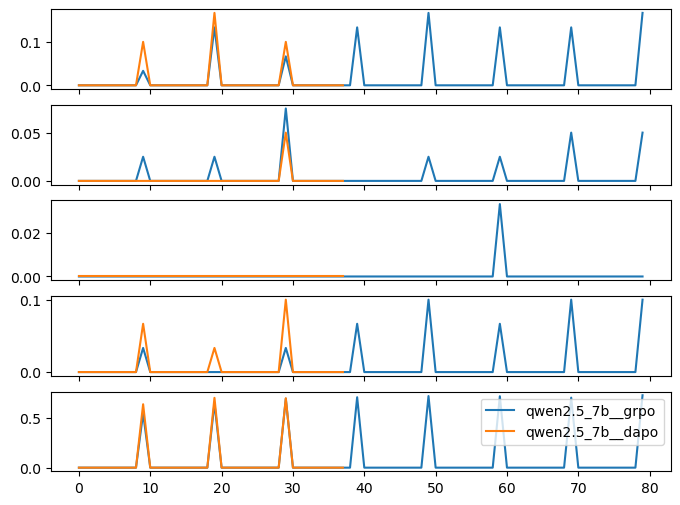

In [89]:
other_validation_keys = [key.replace('mean@8', 'mean@1') for key in validation_keys]
fig, axes = plt.subplots(nrows=len(other_validation_keys), ncols=1, sharex=True, figsize=(8, 6))
for key, ax in zip(other_validation_keys, axes):
    for method, value in logmetrics.items():
        vs = np.array(value[key])
        vs[np.isnan(vs)] = 0
        ax.plot(vs, label=method)

plt.legend()
plt.show()

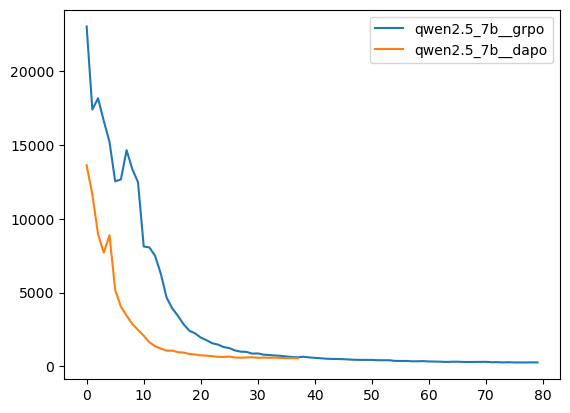

In [90]:
for k in logmetrics.keys():
    try: 
        plt.plot(logmetrics[k]['actor/entropy'], label=k)
    except:
        print(f'failed method: {k}')

plt.legend()
plt.show()